<a href="https://colab.research.google.com/github/Nidhish-p/Cricket-Stats-Analysis/blob/Main/cricinfo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests as rq
from bs4 import BeautifulSoup as bs
import pandas as pd

#for page1
s="https://stats.espncricinfo.com/ci/engine/stats/index.html?class=11;template=results;type=batting"
p=rq.get(s)
obj=bs(p.text,"html.parser")#html5lib
print(obj)
table=obj.find_all(name="tbody")
rows=table[2].find_all(name="tr")
batsmen=pd.DataFrame(columns=["Player Name","Countries","Span","Matches","Innings","NO","Runs","HS","AVG","100s","50s","0"])
for i in rows:
  col=i.find_all(name="td")
  coun=col[0].a.find_next_sibling(text=True)
  data={"Player Name":col[0].contents[0],"Countries":coun,"Span":col[1].contents[0],"Matches":col[2].contents[0],"Innings":col[3].contents[0],"NO":col[4].contents[0],"Runs":col[5].contents[0],"HS":col[6].contents[0],"AVG":col[7].contents[0],"100s":col[8].contents[0],"50s":col[9].contents[0],"0":col[10].contents[0]}
  df1=pd.DataFrame(data,index=[0])
  batsmen=pd.concat([batsmen,df1],ignore_index=True)

#for other pages
k=2
while(k<=3):
  s1=f"https://stats.espncricinfo.com/ci/engine/stats/index.html?class=11;page={k};template=results;type=batting"
  p=rq.get(s1)
  obj=bs(p.text,"html.parser")
  table=obj.find_all(name="tbody")
  rows=table[0].find_all(name="tr")
  for i in rows:
    col=i.find_all(name="td")
    coun=col[0].a.find_next_sibling(text=True)
    data={"Player Name":col[0].contents[0],"Countries":coun,"Span":col[1].contents[0],"Matches":col[2].contents[0],"Innings":col[3].contents[0],"NO":col[4].contents[0],"Runs":col[5].contents[0],"HS":col[6].contents[0],"AVG":col[7].contents[0],"100s":col[8].contents[0],"50s":col[9].contents[0],"0":col[10].contents[0]}
    df1=pd.DataFrame(data,index=[0])
    batsmen=pd.concat([batsmen,df1],ignore_index=True)
  k=k+1


<html><head>
<title>Access Denied</title>
</head><body>
<h1>Access Denied</h1>
 
You don't have permission to access "http://stats.espncricinfo.com/ci/engine/stats/index.html?" on this server.<p>
Reference #18.610de17.1707986516.52758b6
</p></body>
</html>



IndexError: list index out of range

In [ ]:
batsmen=batsmen.fillna(0)
batsmen[["Innings","NO","Runs","HS","100s","50s","0"]]=batsmen[["Innings","NO","Runs","HS","100s","50s","0"]].replace("-",0)
batsmen.rename(columns={"Player Name":"Player_Name","Countries":"Country"},inplace=True)
print(batsmen)

           Player_Name         Country       Span Matches Innings  NO   Runs  \
0         SR Tendulkar           (IND)  1989-2013     664     782  74  34357   
1        KC Sangakkara   (Asia/ICC/SL)  2000-2015     594     666  67  28016   
2           RT Ponting       (AUS/ICC)  1995-2012     560     668  70  27483   
3              V Kohli           (IND)  2008-2024     520     578  86  26704   
4     DPMD Jayawardene       (Asia/SL)  1997-2015     652     725  62  25957   
...                ...             ...        ...     ...     ...  ..    ...   
6802          S Zargar           (Mex)  2019-2019       1       0   0      0   
6803       Zeshan Arif           (Aut)  2019-2019       3       0   0      0   
6804      Ziaur Rahman           (AFG)  2019-2019       1       0   0      0   
6805       Zoheb Malek           (MLT)  2021-2021       1       0   0      0   
6806           Zou Kui           (CHN)  2023-2023       1       0   0      0   

        HS    AVG 100s  50s   0 Avg  
0

In [ ]:
batsmen.to_csv("Batsmen_final.csv",index=False)

In [ ]:
import pandas as pd
batsmen=pd.read_csv("Batsmenfinal.csv")

In [ ]:
batsmen.head()

,Unnamed: 0,Player_name,Country,Span,Matches,Innings,NO,Runs,HS,AVG,100s,50s,0
0,0,SR Tendulkar,(IND),1989-2013,664,782,74,34357,248*,48.52,100,164,34
1,1,KC Sangakkara,(Asia/ICC/SL),2000-2015,594,666,67,28016,319,46.77,63,153,28
2,2,RT Ponting,(AUS/ICC),1995-2012,560,668,70,27483,257,45.95,71,146,39
3,3,V Kohli,(IND),2008-2024,520,578,86,26704,254*,54.27,80,139,34
4,4,DPMD Jayawardene,(Asia/SL),1997-2015,652,725,62,25957,374,39.15,54,136,47


In [ ]:
batsmen["Runs"]=pd.to_numeric(batsmen["Runs"],errors="coerce").astype("Int64")
batsmen["Matches"]=pd.to_numeric(batsmen["Matches"],errors="coerce").astype("Int64")
req_bat=batsmen[(batsmen["Runs"]>=2000) & (batsmen["Matches"]>=30)]
#req_bat.drop("Unnamed: ")
print(req_bat)

     Unnamed: 0       Player_name         Country       Span  Matches  \
0             0      SR Tendulkar           (IND)  1989-2013      664   
1             1     KC Sangakkara   (Asia/ICC/SL)  2000-2015      594   
2             2        RT Ponting       (AUS/ICC)  1995-2012      560   
3             3           V Kohli           (IND)  2008-2024      520   
4             4  DPMD Jayawardene       (Asia/SL)  1997-2015      652   
..          ...               ...             ...        ...      ...   
558         558      Saleem Elahi           (PAK)  1995-2004       61   
559         559          S Ramesh           (IND)  1999-2001       43   
560         560       S Wettimuny            (SL)  1982-1987       58   
561         561        RR Rossouw            (SA)  2014-2023       65   
562         562       DN Sardesai           (IND)  1961-1972       30   

     Innings  NO   Runs    HS    AVG  100s  50s   0  
0        782  74  34357  248*  48.52   100  164  34  
1        666  6

In [ ]:
import requests as rq
from bs4 import BeautifulSoup as bs
import pandas as pd

#for page1
s="https://stats.espncricinfo.com/ci/engine/stats/index.html?class=11;template=results;type=bowling"
p=rq.get(s)
obj=bs(p.text,"html.parser")
table=obj.find_all(name="tbody")
rows=table[0].find_all(name="tr")
bowlers=pd.DataFrame(columns=["Player_Name","Country","Span","Matches","Innings","Balls","Runs","Wickets","BBI","BBM","bow_Avg","eco","SR","5","10"])
for i in rows:
  col=i.find_all(name="td")
  coun=col[0].a.find_next_sibling(text=True)
  data={"Player_Name":col[0].contents[0],"Country":coun,"Span":col[1].contents[0],"Matches":col[2].contents[0],"Innings":col[3].contents[0],"Balls":col[4].contents[0],"Runs":col[5].contents[0],"Wickets":col[6].contents[0],"BBI":col[7].contents[0],"BBM":col[8].contents[0],"bow_Avg":col[9].contents[0],"eco":col[10].contents[0],"SR":col[11].contents[0],"5":col[12].contents[0],"10":col[13].contents[0]}
  df1=pd.DataFrame(data,index=[0])
  bowlers=pd.concat([bowlers,df1],ignore_index=True)

#for other pages
k=2
while(k<=137):
  s1=s.replace("class=11;","class=11;page="+str(k)+";")
  p=rq.get(s1)
  obj=bs(p.text,"html.parser")
  table=obj.find_all(name="tbody")
  rows=table[0].find_all(name="tr")
  for i in rows:
    col=i.find_all(name="td")
    coun=col[0].a.find_next_sibling(text=True)
    data={"Player_Name":col[0].contents[0],"Country":coun,"Span":col[1].contents[0],"Matches":col[2].contents[0],"Innings":col[3].contents[0],"Balls":col[4].contents[0],"Runs":col[5].contents[0],"Wickets":col[6].contents[0],"BBI":col[7].contents[0],"BBM":col[8].contents[0],"bow_Avg":col[9].contents[0],"eco":col[10].contents[0],"SR":col[11].contents[0],"5":col[12].contents[0],"10":col[13].contents[0]}
    df1=pd.DataFrame(data,index=[0])
    bowlers=pd.concat([bowlers,df1],ignore_index=True)
  k=k+1
print(bowlers)

IndexError: list index out of range

In [ ]:
bowlers=pd.read_csv("Bowlersfinal.csv")

In [ ]:
bowlers=bowlers.fillna(0)
bowlers[["Innings","Balls","Runs","Wickets","BBI","BBM","bow_Avg","eco","SR","5","10"]]=bowlers[["Innings","Balls","Runs","Wickets","BBI","BBM","bow_Avg","eco","SR","5","10"]].replace("-",0)
print(bowlers)

      Unnamed: 0        Player_Name         Country       Span  Matches  \
0              0      M Muralidaran   (Asia/ICC/SL)  1992-2011      495   
1              1           SK Warne       (AUS/ICC)  1992-2007      339   
2              2        JM Anderson           (ENG)  2002-2023      396   
3              3           A Kumble      (Asia/IND)  1990-2008      403   
4              4         GD McGrath       (AUS/ICC)  1993-2007      376   
...          ...                ...             ...        ...      ...   
6802        6802  Zulfiqar Ali Shah          (PORT)  2021-2021        1   
6803        6803         Zulqarnain           (PAK)  1985-1989       19   
6804        6804  Zulqarnain Haider           (PAK)  2007-2010        8   
6805        6805             L Zulu       (SWA/SWZ)  2021-2022        6   
6806        6806             P Zuze           (MWI)  2023-2023        4   

      Innings  Balls   Runs  Wickets    BBI     BBM  bow_Avg   eco    SR   5  \
0         583  6313

In [ ]:
bowlers.to_csv("Bowlersfinal.csv")

In [ ]:
bowlers["Wickets"]=pd.to_numeric(bowlers["Wickets"],errors="coerce").astype("Int64")
bowlers["eco"]=pd.to_numeric(bowlers["eco"],errors="coerce").astype(float)
req_bow=bowlers[(bowlers["Wickets"]>=20) & (bowlers["eco"]<=3.5)]
print(req_bow)

      Unnamed: 0     Player_Name         Country       Span  Matches  Innings  \
0              0   M Muralidaran   (Asia/ICC/SL)  1992-2011      495      583   
1              1        SK Warne       (AUS/ICC)  1992-2007      339      464   
2              2     JM Anderson           (ENG)  2002-2023      396      551   
3              3        A Kumble      (Asia/IND)  1990-2008      403      501   
4              4      GD McGrath       (AUS/ICC)  1993-2007      376      493   
...          ...             ...             ...        ...      ...      ...   
1430        1430      Shujauddin           (PAK)  1954-1962       19       25   
1431        1431        KJ Silva            (SL)  1995-1998        8       12   
1432        1432     GTS Stevens           (ENG)  1922-1930       10       17   
1435        1435        P Willey           (ENG)  1976-1986       52       42   
1436        1436  Zulfiqar Ahmed           (PAK)  1952-1956        9       10   

      Balls   Runs  Wickets

In [ ]:
allrounders=pd.merge(req_bat,req_bow,left_on="Player_name",right_on="Player_Name",how="inner",suffixes=("_bat","_bowl"))
print(allrounders)

    Unnamed: 0_bat      Player_name Country_bat   Span_bat  Matches_bat  \
0               21        AR Border       (AUS)  1978-1994          429   
1               30    Javed Miandad       (PAK)  1975-1996          357   
2               38     IVA Richards        (WI)  1974-1991          308   
3               53         GA Gooch       (ENG)  1975-1995          243   
4               66         NJ Astle        (NZ)  1995-2007          308   
..             ...              ...         ...        ...          ...   
70             510        VS Hazare       (IND)  1946-1953           30   
71             528     CG Macartney       (AUS)  1907-1926           35   
72             534        MH Mankad       (IND)  1946-1959           44   
73             538  HDPK Dharmasena        (SL)  1993-2004          172   
74             543      CEL Ambrose        (WI)  1988-2000          274   

    Innings_bat  NO  Runs_bat    HS    AVG  ...  Balls  Runs_bowl  Wickets  \
0           517  83  

In [ ]:
p=allrounders["Country_bat"].unique()
print(p)

[' (AUS)' ' (PAK)' ' (WI)' ' (ENG)' ' (NZ)' ' (SA)' ' (IND)'
 ' (Afr/ICC/SA)' ' (ENG/ICC)' ' (ICC/NZ)' ' (Asia/SL)' ' (Afr/ZIM)'
 ' (AUS/ICC)' ' (Asia/IND)' ' (Afr/SA)' ' (Asia/BAN)' ' (SL)']


In [ ]:
dict1={}
countries=["IND","WI","AUS","SL","ENG","PAK","SA","BAN","NZ","ZIM"]
def num(con_name):
  k=allrounders["Country_bat"].str.contains(con_name).sum()
  return k
no=list(map(num,countries))
print(no)
dict1.update({countries[i]:no[i] for i in range(len(no))})
print(dict1)

[10, 8, 12, 2, 16, 10, 8, 1, 7, 1]
{'IND': 10, 'WI': 8, 'AUS': 12, 'SL': 2, 'ENG': 16, 'PAK': 10, 'SA': 8, 'BAN': 1, 'NZ': 7, 'ZIM': 1}


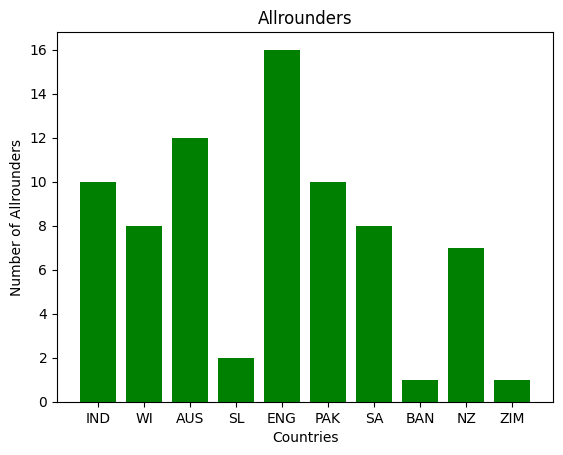

In [ ]:
import matplotlib.pyplot as plt
plt.bar(dict1.keys(),dict1.values(),color="green")
plt.xlabel("Countries")
plt.ylabel("Number of Allrounders")
plt.title("Allrounders")
plt.savefig("allrounder_proj_plot.png")

In [ ]:
import numpy as np
def player_span(date):
  begyr,endyr=map(int,date.split("-"))
  return endyr-begyr+1

def avg_span(con_name):
  df=batsmen[batsmen["Country"].str.contains(con_name)].reset_index(drop=True)
  k=df["Span"].apply(player_span).tolist()
  avg=np.array(k).mean()
  return avg

span=list(map(avg_span,countries))
print(span)


[5.930174563591023, 5.933491686460807, 6.029906542056075, 5.850187265917603, 6.0078226857887875, 6.22478386167147, 4.822612085769981, 5.30635838150289, 6.216138328530259, 6.680473372781065]


([<matplotlib.axis.YTick at 0x7a155540d090>,
 [Text(0, 0.0, '0.000'),
  Text(0, 0.3684210526315789, '0.368'),
  Text(0, 0.7368421052631579, '0.737'),
  Text(0, 1.1052631578947367, '1.105'),
  Text(0, 1.4736842105263157, '1.474'),
  Text(0, 1.8421052631578947, '1.842'),
  Text(0, 2.2105263157894735, '2.211'),
  Text(0, 2.5789473684210527, '2.579'),
  Text(0, 2.9473684210526314, '2.947'),
  Text(0, 3.31578947368421, '3.316'),
  Text(0, 3.6842105263157894, '3.684'),
  Text(0, 4.052631578947368, '4.053'),
  Text(0, 4.421052631578947, '4.421'),
  Text(0, 4.789473684210526, '4.789'),
  Text(0, 5.157894736842105, '5.158'),
  Text(0, 5.526315789473684, '5.526'),
  Text(0, 5.894736842105263, '5.895'),
  Text(0, 6.263157894736842, '6.263'),
  Text(0, 6.63157894736842, '6.632'),
  Text(0, 7.0, '7.000')])

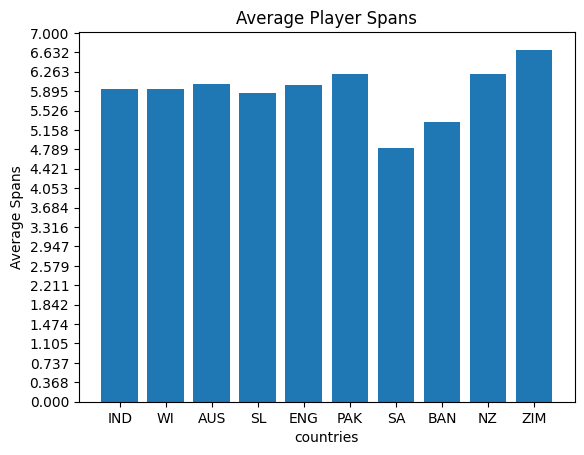

In [ ]:
plt.bar(countries,span)
plt.xlabel("countries")
plt.ylabel("Average Spans")
plt.title("Average Player Spans")
plt.yticks(np.linspace(0,7,20))

In [ ]:
batsmen[["Start Year","End Year"]]=batsmen["Span"].str.split("-",expand=True)
batsmen=batsmen.drop("Span",axis=1)
batsmen.head()

,Unnamed: 0,Player_name,Country,Matches,Innings,NO,Runs,HS,AVG,100s,50s,0,Start Year,End Year
0,0,SR Tendulkar,(IND),664,782,74,34357,248*,48.52,100,164,34,1989,2013
1,1,KC Sangakkara,(Asia/ICC/SL),594,666,67,28016,319,46.77,63,153,28,2000,2015
2,2,RT Ponting,(AUS/ICC),560,668,70,27483,257,45.95,71,146,39,1995,2012
3,3,V Kohli,(IND),520,578,86,26704,254*,54.27,80,139,34,2008,2024
4,4,DPMD Jayawardene,(Asia/SL),652,725,62,25957,374,39.15,54,136,47,1997,2015
